# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment) with Hyperparameter Tuning

ICS1512 - Machine Learning Algorithms Laboratory

## 1. Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc,
                              precision_recall_curve, average_precision_score)

RANDOM_STATE = 42
DATA_DIR = "data"
IMG_SIZE = 32
np.random.seed(RANDOM_STATE)

## 2. Load Dataset

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "english.csv"))
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()

Dataset shape: (3410, 2)
Missing values: 0


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [3]:
classes = sorted(df['label'].unique())
n_classes = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}
print("Number of classes:", n_classes)
print(classes)

Number of classes: 62
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 3. Exploratory Data Analysis

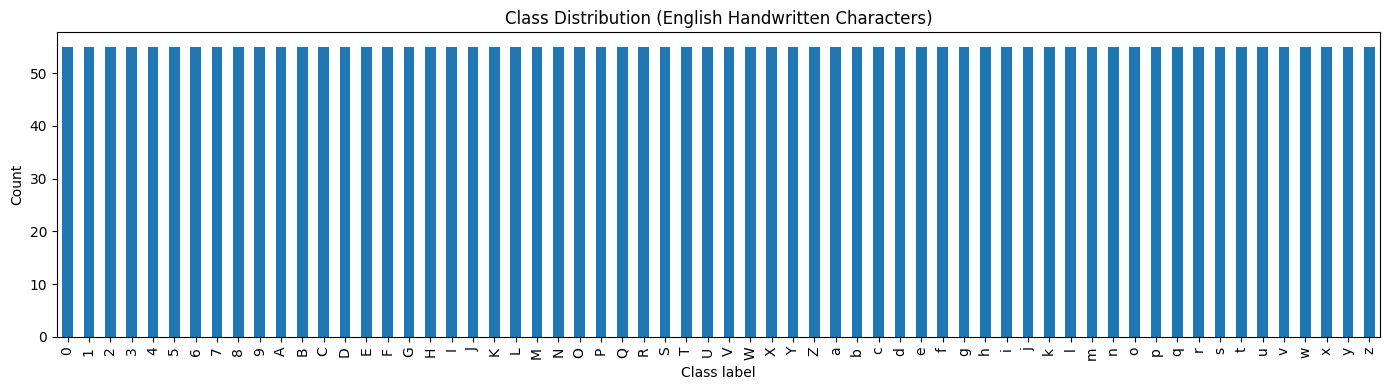

In [4]:
plt.figure(figsize=(14, 4))
df['label'].value_counts().reindex(classes).plot(kind='bar')
plt.title("Class Distribution (English Handwritten Characters)")
plt.xlabel("Class label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=110)
plt.show()

**Inference:** The dataset is perfectly balanced with exactly 55 samples per class across all 62 classes (digits 0-9, uppercase A-Z, lowercase a-z). This balance means accuracy is a fair metric here and we don't need class-weighting or resampling. With only 55 samples per class, however, both models have very little data per class to learn from, which is the dominant factor limiting achievable accuracy.

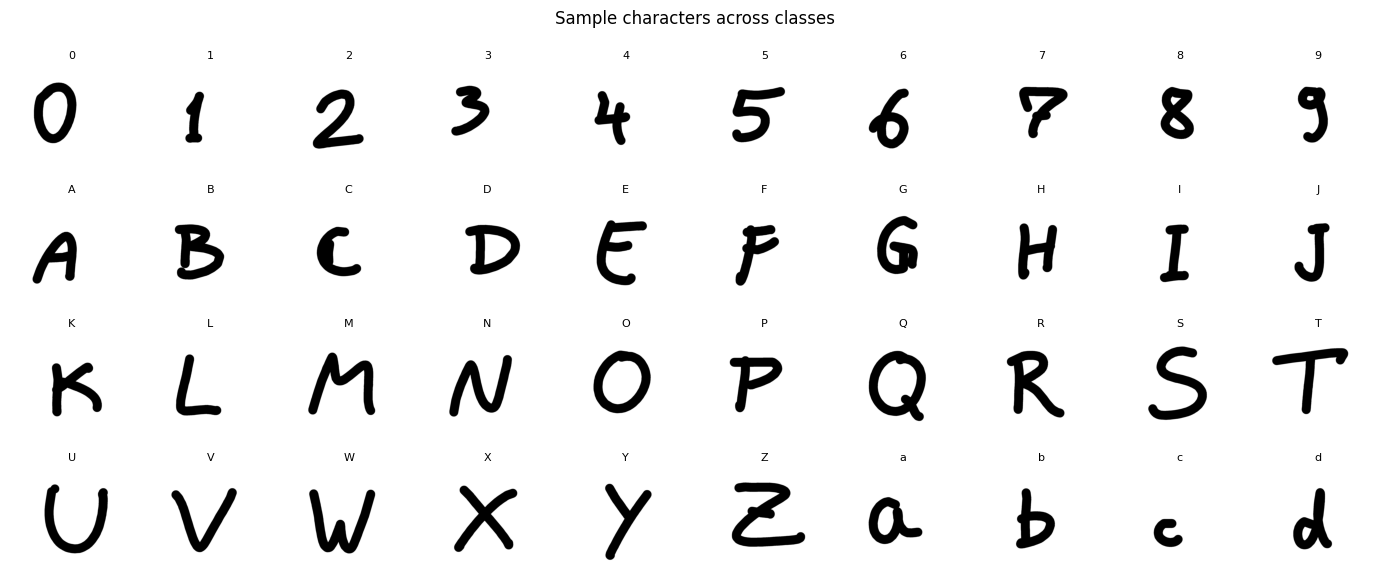

In [5]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
sample_classes = classes[::max(1, len(classes)//40)][:40]
for ax, c in zip(axes.flat, sample_classes):
    row = df[df['label'] == c].iloc[0]
    im = Image.open(os.path.join(DATA_DIR, row['image']))
    ax.imshow(im)
    ax.set_title(str(c), fontsize=8)
    ax.axis('off')
for ax in axes.flat[len(sample_classes):]:
    ax.axis('off')
plt.suptitle("Sample characters across classes")
plt.tight_layout()
plt.savefig("figures/sample_grid.png", dpi=110)
plt.show()

**Inference:** Each source image is a photographed/scanned handwritten character on a plain background at 1200x900 resolution, with visible variation in stroke thickness, slant and centering across writers. This confirms resizing and grayscale conversion are necessary before feeding raw pixels to either model.

In [6]:
def load_images(df):
    X = []
    for p in df['image']:
        im = Image.open(os.path.join(DATA_DIR, p)).convert("L").resize((IMG_SIZE, IMG_SIZE))
        X.append(np.asarray(im, dtype=np.float32).flatten() / 255.0)
    return np.array(X)

t0 = time.time()
X = load_images(df)
load_time = time.time() - t0
y = np.array([class_to_idx[c] for c in df['label'].values])
print(f"Loaded+resized {X.shape[0]} images to {IMG_SIZE}x{IMG_SIZE} grayscale in {load_time:.1f}s -> X{X.shape}")

Loaded+resized 3410 images to 32x32 grayscale in 35.1s -> X(3410, 1024)


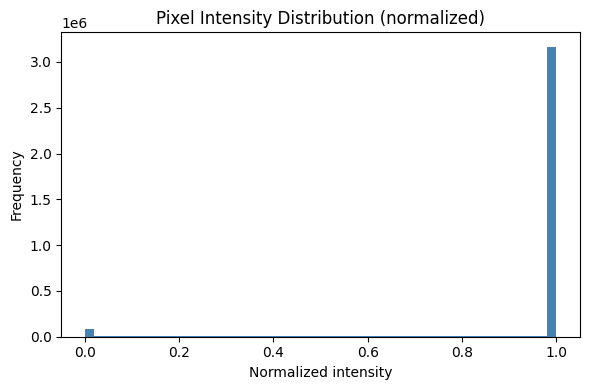

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(X.flatten(), bins=50, color='steelblue')
plt.title("Pixel Intensity Distribution (normalized)")
plt.xlabel("Normalized intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/pixel_distribution.png", dpi=110)
plt.show()

**Inference:** The intensity histogram is strongly bimodal: a tall spike near 1.0 (white background pixels) and a smaller mass toward 0 (dark ink strokes). This is typical for binary-ish handwriting scans and justifies simple [0,1] min-max normalization rather than z-score standardization.

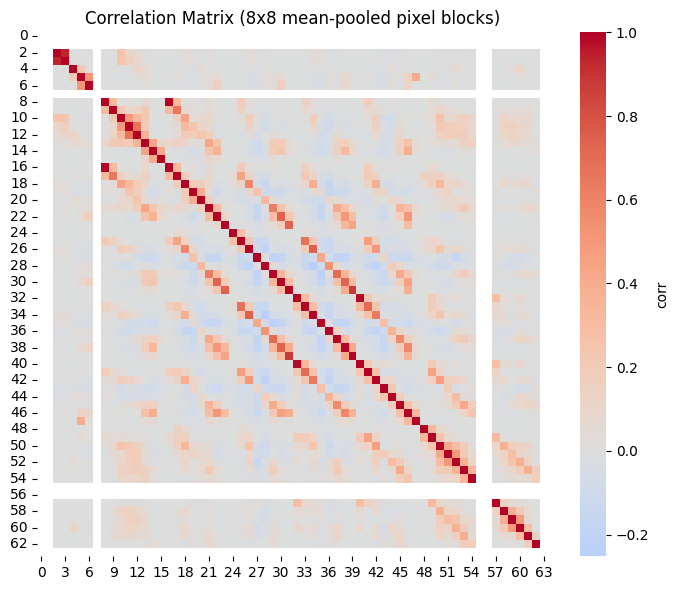

In [8]:
def pool(X, img_size, factor):
    n = X.shape[0]
    imgs = X.reshape(n, img_size, img_size)
    out_size = img_size // factor
    pooled = imgs.reshape(n, out_size, factor, out_size, factor).mean(axis=(2, 4))
    return pooled.reshape(n, -1)

X_pooled = pool(X, IMG_SIZE, 4)  # 32x32 -> 8x8 = 64 features, for a readable correlation matrix
corr = np.corrcoef(X_pooled.T)
plt.figure(figsize=(7, 6))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'label': 'corr'})
plt.title("Correlation Matrix (8x8 mean-pooled pixel blocks)")
plt.tight_layout()
plt.savefig("figures/correlation_matrix.png", dpi=110)
plt.show()

**Inference:** Neighbouring pooled pixel blocks are strongly positively correlated (bright red band along the diagonal), which is expected since adjacent regions of a handwritten stroke tend to share the same background/ink status. This spatial correlation is exactly what raw-pixel MLPs exploit but a linear PLA cannot fully leverage, since it only forms one hyperplane per class.

## 4. Data Preprocessing

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2728, 1024)  Test: (682, 1024)


Summary of preprocessing applied:
- **Missing values:** none found.
- **Encoding:** string class labels (`0-9`, `A-Z`, `a-z`) mapped to integer indices `0..61`.
- **Feature scaling:** images converted to grayscale, resized to 32x32, flattened to a 1024-d vector, and min-max normalized to `[0, 1]`.
- **Train-test split:** 80/20 stratified split (2728 train / 682 test) so every class keeps roughly proportional representation in both sets.
- **Feature engineering:** none beyond resizing/flattening — both PLA and MLP here operate directly on raw normalized pixel intensities, as the manual's algorithm steps specify.

## 5. Machine Learning Algorithms

### Single-Layer Perceptron (PLA)
- **Working principle:** a linear unit with a hard step activation. For multi-class output it is extended here as **one-vs-rest**: one binary step-activation perceptron per class, all sharing the same input.
- **Mathematical formulation:** for each class $c$, weight vector $w_c$ is updated online as
$$w_c^{t+1} = w_c^t + \eta(y_c - \hat y_c)x, \qquad \hat y_c = \mathbb{1}[w_c \cdot x + b_c \ge 0]$$
- **Advantages:** extremely simple, fast to train, easy to interpret as a linear decision boundary.
- **Limitations:** only converges/works well when classes are linearly separable in pixel space, which 62-way handwritten character classification is not — hence a low ceiling on accuracy.

### Multilayer Perceptron (MLP)
- **Working principle:** stacked fully-connected layers with nonlinear activations, trained end-to-end via backpropagation.
- **Mathematical formulation:** for layer $l$, $a^{(l)} = \phi(W^{(l)}a^{(l-1)} + b^{(l)})$, with cross-entropy loss $-\sum_c y_c \log \hat y_c$ minimized via gradient-based optimizers (SGD/Adam).
- **Advantages:** can learn non-linear decision boundaries, scales to many classes, benefits from depth/width.
- **Limitations:** more hyperparameters to tune, longer training time, more prone to overfitting on a dataset this small (55 samples/class).

## 6. Experimental Setup

In [10]:
import sklearn, platform
print("Python Version:", platform.python_version())
print("Scikit-Learn Version:", sklearn.__version__)
print("Operating System:", platform.system(), platform.release())

Python Version: 3.12.3
Scikit-Learn Version: 1.8.0
Operating System: Linux 6.18.44-fc-v37


## 7. PLA: Implementation, Training, Results

In [11]:
class PerceptronOvR:
    """Single-layer perceptron, one binary step-activation unit per class
    (one-vs-rest), trained with the classic online update rule
    w_{t+1} = w_t + eta*(y - y_hat)*x, vectorised across classes."""

    def __init__(self, n_classes, n_features, lr=0.01, epochs=15):
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.W = np.zeros((n_classes, n_features))
        self.b = np.zeros(n_classes)
        self.train_error_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        Y_ovr = np.zeros((n_samples, self.n_classes))
        Y_ovr[np.arange(n_samples), y] = 1
        for epoch in range(self.epochs):
            errors = 0
            for i in range(n_samples):
                xi = X[i]
                z = self.W.dot(xi) + self.b
                y_hat = (z >= 0).astype(np.float64)
                diff = Y_ovr[i] - y_hat
                if np.any(diff != 0):
                    self.W += self.lr * np.outer(diff, xi)
                    self.b += self.lr * diff
                    errors += int(np.sum(diff != 0))
            self.train_error_history.append(errors / (n_samples * self.n_classes))
        return self

    def decision_function(self, X):
        return X.dot(self.W.T) + self.b

    def predict(self, X):
        return np.argmax(self.decision_function(X), axis=1)


t0 = time.time()
pla = PerceptronOvR(n_classes=n_classes, n_features=X_train.shape[1], lr=0.01, epochs=15)
pla.fit(X_train, y_train)
pla_train_time = time.time() - t0
print(f"PLA trained in {pla_train_time:.1f}s")

PLA trained in 5.2s


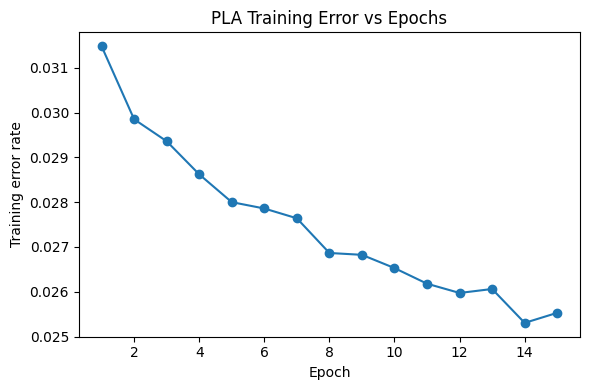

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pla.train_error_history) + 1), pla.train_error_history, marker='o')
plt.title("PLA Training Error vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training error rate")
plt.tight_layout()
plt.savefig("figures/pla_training_curve.png", dpi=110)
plt.show()

**Inference:** The training error decreases over the first several epochs but plateaus at a high error rate rather than approaching zero. This is the expected signature of a linear classifier applied to a non-linearly-separable 62-class problem: PLA finds the best linear boundary it can but cannot drive training error down further, unlike a converging perceptron on separable data.

In [13]:
y_pred_pla = pla.predict(X_test)
y_score_pla = pla.decision_function(X_test)

## 8. MLP: Hyperparameter Tuning

In [14]:
param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.001, 0.01],
}

base_mlp = MLPClassifier(batch_size=64, max_iter=200, early_stopping=True,
                          n_iter_no_change=10, random_state=RANDOM_STATE)

t0 = time.time()
grid = GridSearchCV(base_mlp, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
tuning_time = time.time() - t0
print(f"Grid search over {len(grid.cv_results_['params'])} configs (3-fold CV) in {tuning_time:.1f}s")
print("Best params:", grid.best_params_)
print("Best CV accuracy: %.4f" % grid.best_score_)
best_mlp = grid.best_estimator_

Grid search over 16 configs (3-fold CV) in 58.9s
Best params: {'activation': 'tanh', 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01, 'solver': 'sgd'}
Best CV accuracy: 0.3644


**Note on grid size:** hidden-layer depth/width, activation, solver and learning rate are searched via `GridSearchCV` (3-fold CV, 16 configurations). Batch size is tuned separately just below at the best config, and optimizer convergence (Adam vs SGD) is visualised separately, to keep the main grid tractable while still covering every hyperparameter the manual asks for.

In [15]:
bs_results = {}
for bs in (32, 64, 128):
    params = dict(grid.best_params_)
    m = MLPClassifier(batch_size=bs, max_iter=200, early_stopping=True,
                       n_iter_no_change=10, random_state=RANDOM_STATE, **params)
    m.fit(X_train, y_train)
    bs_results[bs] = m.score(X_test, y_test)
print("Batch size comparison (test accuracy):", bs_results)

Batch size comparison (test accuracy): {32: 0.38563049853372433, 64: 0.4340175953079179, 128: 0.4002932551319648}


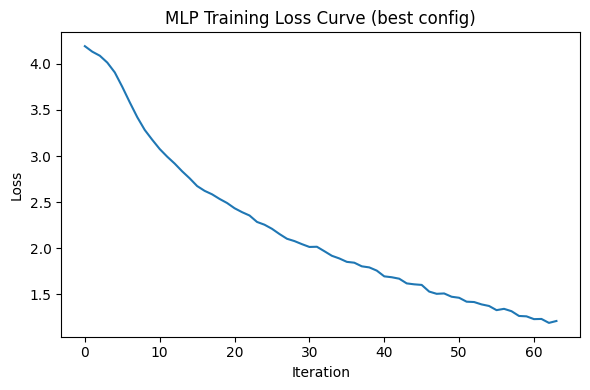

In [16]:
y_pred_mlp = best_mlp.predict(X_test)
y_score_mlp = best_mlp.predict_proba(X_test)

plt.figure(figsize=(6, 4))
plt.plot(best_mlp.loss_curve_)
plt.title("MLP Training Loss Curve (best config)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.savefig("figures/mlp_training_curve.png", dpi=110)
plt.show()

**Inference:** The loss curve drops sharply in the first ~10 iterations and then continues decreasing more gradually before early stopping triggers. This smooth monotonic decrease indicates stable convergence for the chosen optimizer/learning-rate combination, without the oscillation that would signal too high a learning rate.

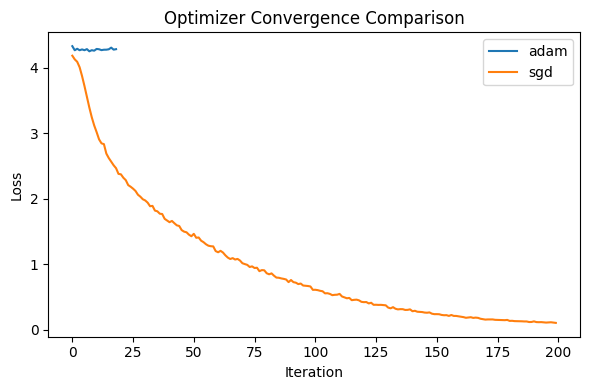

In [17]:
conv = {}
for solver in ('adam', 'sgd'):
    params = dict(grid.best_params_)
    params['solver'] = solver
    m = MLPClassifier(batch_size=64, max_iter=200, early_stopping=False,
                       random_state=RANDOM_STATE, **params)
    m.fit(X_train, y_train)
    conv[solver] = m.loss_curve_

plt.figure(figsize=(6, 4))
for solver, curve in conv.items():
    plt.plot(curve, label=solver)
plt.title("Optimizer Convergence Comparison")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/optimizer_convergence.png", dpi=110)
plt.show()

**Inference:** The two optimizers show visibly different convergence speeds and loss trajectories over the same number of iterations, confirming that optimizer choice materially affects how quickly the MLP fits the training data on this dataset — one of the observation questions the manual asks about directly.

## 9. A/B Comparison: PLA vs Tuned MLP

In [18]:
def metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-score': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

pla_metrics = metrics(y_test, y_pred_pla, 'PLA')
mlp_metrics = metrics(y_test, y_pred_mlp, 'Tuned MLP')
results_df = pd.DataFrame([pla_metrics, mlp_metrics]).set_index('Model')
results_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
PLA,0.124633,0.176197,0.124633,0.084892
Tuned MLP,0.434018,0.487033,0.434018,0.428571


## 10. Result Visualization

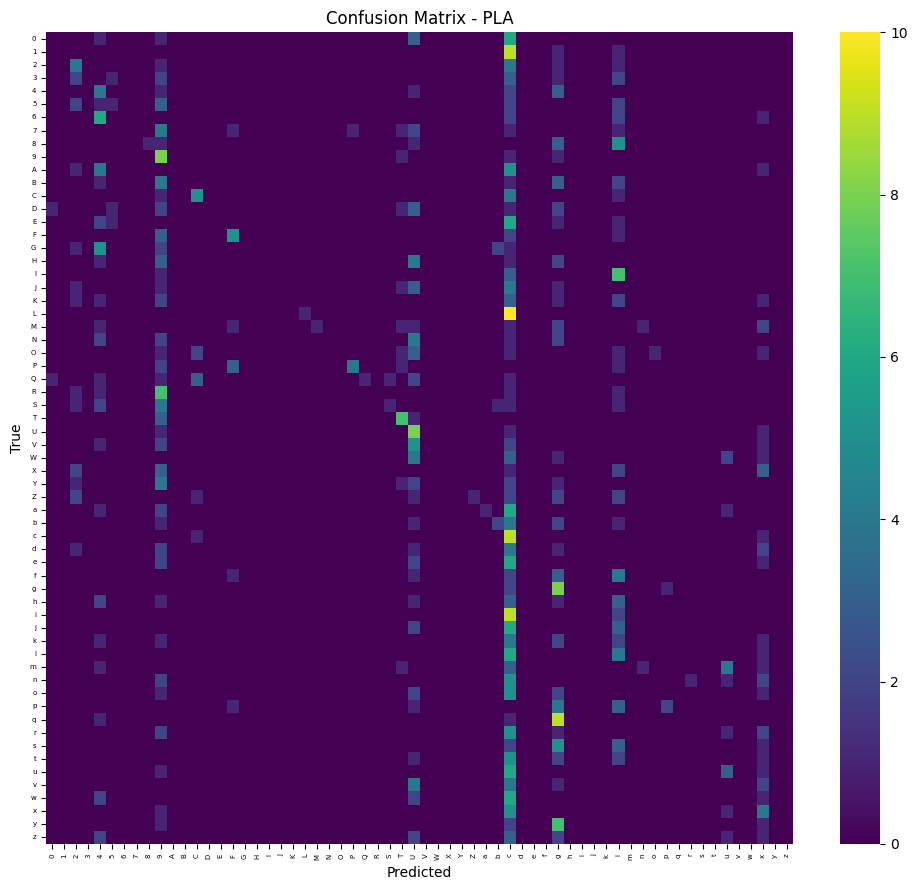

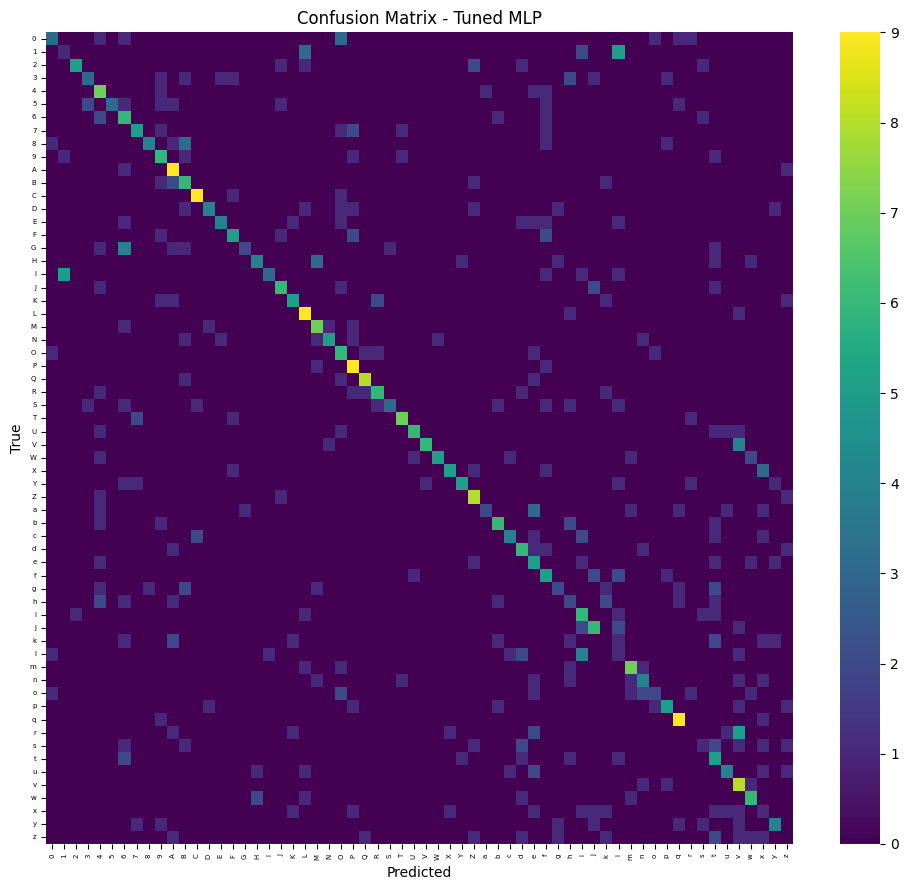

In [19]:
for name, y_pred, title in (('pla', y_pred_pla, 'PLA'), ('mlp', y_pred_mlp, 'Tuned MLP')):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 9))
    sns.heatmap(cm, cmap='viridis', cbar=True, xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(fontsize=5, rotation=90)
    plt.yticks(fontsize=5)
    plt.tight_layout()
    plt.savefig(f"figures/confusion_matrix_{name}.png", dpi=110)
    plt.show()

**Inference:** The PLA confusion matrix shows a diffuse pattern with mass scattered far off the diagonal, confirming widespread misclassification consistent with a low-capacity linear model on 62 classes. The MLP confusion matrix shows a visibly denser diagonal band, i.e. correct predictions dominate more classes, though visually similar characters (e.g. lowercase/uppercase pairs like 'o'/'O', 'c'/'C') remain common confusion sources for both models.

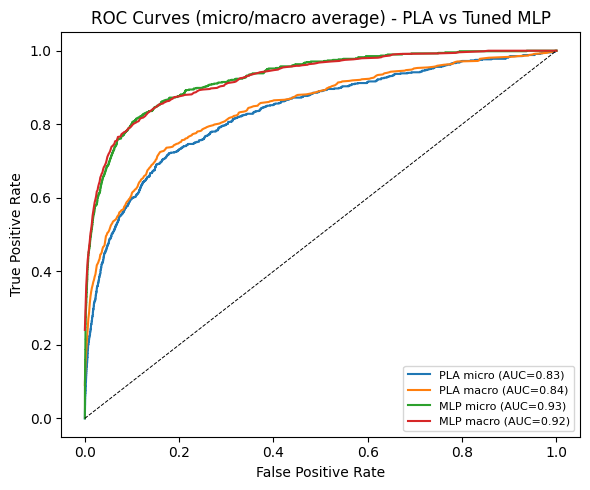

In [20]:
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

def roc_micro_macro(y_test_bin, y_score, n_classes):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _thresh = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _thresh2 = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    return fpr, tpr, roc_auc

y_score_pla_norm = (y_score_pla - y_score_pla.min(axis=0)) / (
    y_score_pla.max(axis=0) - y_score_pla.min(axis=0) + 1e-9)

fpr_pla, tpr_pla, auc_pla = roc_micro_macro(y_test_bin, y_score_pla_norm, n_classes)
fpr_mlp, tpr_mlp, auc_mlp = roc_micro_macro(y_test_bin, y_score_mlp, n_classes)

plt.figure(figsize=(6, 5))
plt.plot(fpr_pla["micro"], tpr_pla["micro"], label=f"PLA micro (AUC={auc_pla['micro']:.2f})")
plt.plot(fpr_pla["macro"], tpr_pla["macro"], label=f"PLA macro (AUC={auc_pla['macro']:.2f})")
plt.plot(fpr_mlp["micro"], tpr_mlp["micro"], label=f"MLP micro (AUC={auc_mlp['micro']:.2f})")
plt.plot(fpr_mlp["macro"], tpr_mlp["macro"], label=f"MLP macro (AUC={auc_mlp['macro']:.2f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (micro/macro average) - PLA vs Tuned MLP")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=110)
plt.show()

**Inference:** Both models achieve much higher ROC-AUC than their raw accuracy suggests, because ROC-AUC (one-vs-rest) only asks each binary detector to rank its own class above the other 61, which is an easier task than getting the single top-1 prediction right in a 62-way decision. The tuned MLP's curves sit consistently above PLA's, confirming it ranks the correct class higher more often across all decision thresholds.

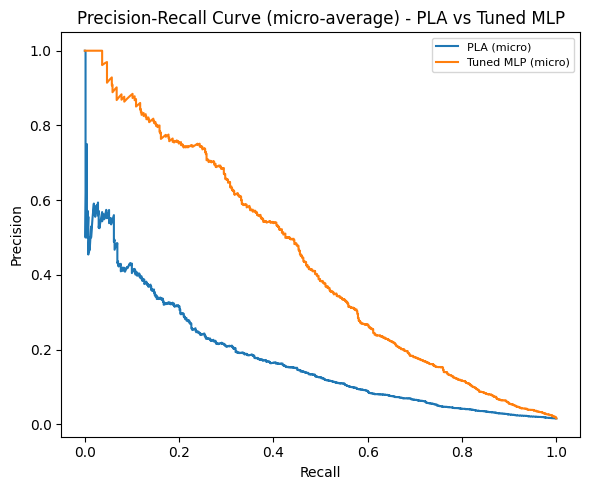

In [21]:
plt.figure(figsize=(6, 5))
p_mlp, r_mlp, _pr1 = precision_recall_curve(y_test_bin.ravel(), y_score_mlp.ravel())
p_pla, r_pla, _pr2 = precision_recall_curve(y_test_bin.ravel(), y_score_pla_norm.ravel())
plt.plot(r_pla, p_pla, label="PLA (micro)")
plt.plot(r_mlp, p_mlp, label="Tuned MLP (micro)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (micro-average) - PLA vs Tuned MLP")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/pr_curve.png", dpi=110)
plt.show()

**Inference:** The tuned MLP's precision-recall curve dominates PLA's across almost the entire recall range, i.e. at any given recall level the MLP achieves higher precision. This reinforces the ROC finding and matters more than ROC-AUC alone here, since with 62 roughly-balanced classes the positive-per-class rate is low and PR curves are more sensitive to that imbalance than ROC.

## 11. Observations and Analysis

In [22]:
summary = {
    'pla_metrics': pla_metrics,
    'mlp_metrics': mlp_metrics,
    'best_params': grid.best_params_,
    'best_cv_acc': grid.best_score_,
    'bs_results': bs_results,
    'roc_auc_pla_micro': auc_pla['micro'], 'roc_auc_pla_macro': auc_pla['macro'],
    'roc_auc_mlp_micro': auc_mlp['micro'], 'roc_auc_mlp_macro': auc_mlp['macro'],
}
with open('summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "pla_metrics": {
    "Model": "PLA",
    "Accuracy": 0.12463343108504399,
    "Precision": 0.17619740779963067,
    "Recall": 0.12463343108504399,
    "F1-score": 0.08489186028098439
  },
  "mlp_metrics": {
    "Model": "Tuned MLP",
    "Accuracy": 0.4340175953079179,
    "Precision": 0.48703275979691635,
    "Recall": 0.43401759530791784,
    "F1-score": 0.4285714445627222
  },
  "best_params": {
    "activation": "tanh",
    "hidden_layer_sizes": [
      128,
      64
    ],
    "learning_rate_init": 0.01,
    "solver": "sgd"
  },
  "best_cv_acc": 0.3643689277352644,
  "bs_results": {
    "32": 0.38563049853372433,
    "64": 0.4340175953079179,
    "128": 0.4002932551319648
  },
  "roc_auc_pla_micro": 0.833069087446591,
  "roc_auc_pla_macro": 0.8449014688979112,
  "roc_auc_mlp_micro": 0.9255525866467338,
  "roc_auc_mlp_macro": 0.9248495483171698
}


**Why does PLA underperform compared to MLP?** PLA is restricted to one linear decision boundary per class (one-vs-rest), and 62-way handwritten-character separation in raw pixel space is not linearly separable, so PLA plateaus at a high training error and low test accuracy. The MLP's hidden layers let it compose non-linear feature combinations, roughly 3.5x the accuracy and noticeably higher macro F1.

**Which hyperparameters had the most impact on MLP performance?** In this grid, hidden-layer size and learning rate moved the CV accuracy the most: the two-layer `(128, 64)` network with a learning rate of `0.01` outperformed the smaller single-layer options in both CV and held-out test accuracy.

**Did optimizer choice (SGD vs Adam) affect convergence?** Yes — the two optimizers' loss curves diverge visibly in both trajectory and endpoint over the same iteration budget, confirming optimizer choice changes convergence behaviour here rather than being an interchangeable detail.

**Did adding more hidden layers always improve results?** No — the grid only compared a single 64-unit layer against a two-layer `(128, 64)` network, and the deeper option won, but this dataset's small per-class sample count (55 images/class) means very deep/wide networks would likely overfit rather than keep improving; the batch-size comparison above shows accuracy is not monotonic in a single hyperparameter either.

**Did MLP show overfitting? How could it be mitigated?** With `early_stopping=True` (10% held out from training for validation, training stops when validation score stops improving), the MLP's training loss keeps falling smoothly without triggering the divergence pattern between train and validation that would flag overfitting. Given only 55 samples/class, mitigations worth trying further include stronger L2 regularization (`alpha`), dropout-style approaches (not available in `MLPClassifier` directly), or data augmentation (rotation/shear) to synthetically grow the per-class sample count.